## CA 4 - Part 2, LLMs Spring 2025

- **Name:**
- **Student ID:**

---
#### Your submission should be named using the following format: `CA4_LASTNAME_STUDENTID.ipynb`.

---

TA Email: miladmohammadi@ut.ac.ir

##### *How to do this problem set:*

- Some questions require writing Python code and computing results, and the rest of them have written answers. For coding problems, you will have to fill out all code blocks that say `YOUR CODE HERE`.

- For text-based answers, you should replace the text that says ```Your Answer Here``` with your actual answer.

- There is no penalty for using AI assistance on this homework as long as you fully disclose it in the final cell of this notebook (this includes storing any prompts that you feed to large language models). That said, anyone caught using AI assistance without proper disclosure will receive a zero on the assignment (we have several automatic tools to detect such cases). We're literally allowing you to use it with no limitations, so there is no reason to lie!

---

##### *Academic honesty*

- We will audit the Colab notebooks from a set number of students, chosen at random. The audits will check that the code you wrote actually generates the answers in your notebook. If you turn in correct answers on your notebook without code that actually generates those answers, we will consider this a serious case of cheating.

- We will also run automatic checks of Colab notebooks for plagiarism. Copying code from others is also considered a serious case of cheating.

---

## Text2SQL

In this section, you will progressively build and evaluate multiple Text-to-SQL pipelines. You’ll start with a simple prompting-based baseline, then design a graph-based routing system using chain-of-thought and schema reasoning, and finally construct a ReAct agent that interacts with the schema via tools. Each stage demonstrates a different strategy for generating SQL from natural language using LLMs.

### Initializations

This section prepares the environment and initializes the LLM model (Gemini) to be used in later parts of the notebook.

In [7]:
%pip install -r requirements.txt

#### Load API Key (2 Points)

**Task:** Load the Gemini API key stored in the `.env` file and set it as an environment variable so it can be used to authenticate API requests later.

* Use `dotenv` to load the file.
* Extract the API key with `os.getenv`.

In [8]:
#YOUR CODE HERE

import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

# بارگذاری API Key
load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")


#### Create ChatModel (3 Points)

**Task:** Create an instance of the Gemini LLM using LangChain. You should configure the model with proper parameters for our task.

Note: You may use any model that supports Structured Output and Tool Use. We recommend using gemini-2.5-flash-preview-05-20 from Google AI Studio, as it offers a generous free tier.

In [9]:
!pip install -q langchain langchain-google-genai google-generativeai

In [10]:
!pip install -q google-generativeai

In [11]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI


model = ChatGoogleGenerativeAI(
    model= "gemini-2.5-flash-preview-05-20",
    temperature=1.0,
    max_retries=2,
    google_api_key=api_key,
)

### Baseline

In this section, you'll build a simple baseline pipeline that directly converts a question and schema into a SQL query using a single prompt.

#### Baseline Function (5 Points)

**Task:** Implement a function that sends a system message defining the task, and a user message containing the input question and schema. The LLM should return the SQL query formatted as: "```sql\n[query]```"

In [12]:
def run_baseline(question: str, schema: str):
    prompt = [
        {"role": "system", "content": "You are a helpful assistant that converts natural language questions into SQL queries based on the given database schema. Return only the SQL in a markdown block."},
        {"role": "user", "content": f"Question: {question}\nSchema:\n{schema}"}
    ]
    response = model.invoke(prompt)
    return response.content

#### Run and Evaluate (Estimated Run Time 5-10min)

Run your baseline function over the dataset provided.

In [3]:
import zipfile

with zipfile.ZipFile("CA4_Part2.zip", 'r') as zip_ref:
    zip_ref.extractall('.')  # یا فقط zip_ref.extractall()

In [ ]:
import os

root_dir = "/content/data"  # یا هر دایرکتوری‌ای که می‌خوای اصلاح بشه

for dirpath, dirnames, filenames in os.walk(root_dir, topdown=False):
    # اول فایل‌ها رو تغییر نام می‌دیم
    for filename in filenames:
        old_path = os.path.join(dirpath, filename)
        new_filename = filename.lower()
        new_path = os.path.join(dirpath, new_filename)
        if old_path != new_path:
            os.rename(old_path, new_path)

    # بعد فولدرها (از پایین به بالا برای جلوگیری از مشکل در دسترسی)
    for dirname in dirnames:
        old_path = os.path.join(dirpath, dirname)
        new_dirname = dirname.lower()
        new_path = os.path.join(dirpath, new_dirname)
        if old_path != new_path:
            os.rename(old_path, new_path)


In [18]:
from method_run import run_method
import re

def function_template(item):
    result = run_baseline(item['question'], item['schema'])
    # First try to extract query from markdown SQL block
    match = re.search(r'```sql\n(.*?)```', result, re.DOTALL)
    if match:
        query = match.group(1).strip()
    else:
        # If no markdown block found, try to extract just SQL query
        query = result.strip()
        # Remove any ```sql or ``` if present without proper formatting
        query = re.sub(r'```sql|```', '', query).strip()

    print(f"Question: {item['question']}")
    print(f"Schema: {item['schema']}")
    print(f"Generated SQL: {query}\n")

    return {**item, 'sql': query}

run_method(function_template, SLEEP_TIME=10)

#Run on mode=nano if you want to test it on a smaller dataset
run_method(function_template, SLEEP_TIME=10, mode="nano")

  0%|          | 0/18 [00:00<?, ?it/s]

Question: Find the percentage of atoms with single bond. (Evidence: single bond refers to bond_type = '-'; percentage = DIVIDE(SUM(bond_type = '-'), COUNT(bond_id)) as percentage)
Schema: atom (atom_id, molecule_id, element)
bond (bond_id, molecule_id, bond_type)
connected (atom_id, atom_id2, bond_id)
molecule (molecule_id, label)

Generated SQL: SELECT
  CAST(SUM(CASE WHEN bond_type = '-' THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(bond_id)
FROM bond;



  6%|▌         | 1/18 [00:12<03:27, 12.21s/it]

Question: Indicate which atoms are connected in non-carcinogenic type molecules. (Evidence: label = '-' means molecules are non-carcinogenic)
Schema: atom (atom_id, molecule_id, element)
bond (bond_id, molecule_id, bond_type)
connected (atom_id, atom_id2, bond_id)
molecule (molecule_id, label)

Generated SQL: SELECT
  T2.atom_id,
  T2.atom_id2
FROM molecule AS T1
INNER JOIN connected AS T2
  ON T1.molecule_id = T2.molecule_id
WHERE
  T1.label = '-';



 11%|█         | 2/18 [00:23<03:05, 11.61s/it]

...

Question: Find the name and date of events with expenses for pizza that were more than fifty dollars but less than a hundred dollars. (Evidence: name of event refers to event_name; date of event refers to event_date; expenses for pizza refers to expense_description = 'Pizza' where cost > 50 and cost < 100)
Schema: event (event_id, event_name, event_date, type, notes, location, status)
major (major_id, major_name, department, college)
zip_code (zip_code, type, city, county, state, short_state)
attendance (link_to_event, link_to_member)
budget (budget_id, category, spent, remaining, amount, event_status, link_to_event)
expense (expense_id, expense_description, expense_date, cost, approved, link_to_member, link_to_budget)
income (income_id, date_received, amount, source, notes, link_to_member)
member (member_id, first_name, last_name, email, position, t_shirt_size, phone, zip, link_to_major)

Generated SQL: SELECT
  e.event_name,
  e.event_date
FROM event AS e
JOIN budget AS b
  ON e.even

 80%|████████  | 4/5 [00:50<00:12, 12.75s/it]

Question: Based on the total cost for all event, what is the percentage of cost for Yearly Kickoff event? (Evidence: DIVIDE(SUM(cost where event_name = 'Yearly Kickoff'), SUM(cost)) * 100)
Schema: event (event_id, event_name, event_date, type, notes, location, status)
major (major_id, major_name, department, college)
zip_code (zip_code, type, city, county, state, short_state)
attendance (link_to_event, link_to_member)
budget (budget_id, category, spent, remaining, amount, event_status, link_to_event)
expense (expense_id, expense_description, expense_date, cost, approved, link_to_member, link_to_budget)
income (income_id, date_received, amount, source, notes, link_to_member)
member (member_id, first_name, last_name, email, position, t_shirt_size, phone, zip, link_to_major)

Generated SQL: SELECT
  SUM(CASE WHEN T3.event_name = 'Yearly Kickoff' THEN T1.cost ELSE 0 END) * 100.0 / SUM(T1.cost)
FROM expense AS T1
INNER JOIN budget AS T2
  ON T1.link_to_budget = T2.budget_id
INNER JOIN event

100%|██████████| 5/5 [01:01<00:00, 12.38s/it]

Starting to compare without knowledge for ex
Process finished successfully
start calculate
                     simple               moderate             challenging          total               
count                1                    1                    3                    5                   
======================================    ACCURACY    =====================================
accuracy             0.00                 0.00                 33.33                20.00               
Finished evaluation



In [19]:
import os

folder = "data/dev_databases/student_club/database_description"

for filename in os.listdir(folder):
    src = os.path.join(folder, filename)
    dst = os.path.join(folder, filename.lower())
    os.rename(src, dst)

In [20]:
!ls data/dev_databases/student_club/database_description

attendance.csv	event.csv    income.csv  member.csv
budget.csv	expense.csv  major.csv	 zip_code.csv


### Chain/Router

Here, you will build a more advanced system that routes the query through different paths based on question difficulty. Easier questions go straight to query generation; harder ones go through schema path extraction first.

#### Define State (5 Points)

**Task:** Define a `RouterGraphState` using `MessagesState` and `pydantic` that contains:
* The input question and schema
* The predicted difficulty level
* The extracted schema path
* The final query

In [21]:
from langgraph.graph import MessagesState
from typing import Optional

class RouterGraphState(MessagesState):
    question: str
    schema: str
    question_difficulty: Optional[str] = None
    schema_path: Optional[str] = None
    query: Optional[str] = None

#### Node: Analyser (5 Points)

**Task:** Build a node that:
* Accepts a question and schema
* Analyzes the difficulty (simple/moderate/challanging)
* Uses the LLM’s structured output feature to return the difficulty

**Steps**:

1. Define a Pydantic class to hold the expected structured output.
2. Use structure output mode of LLM to bind it to the model.

In [22]:
from pydantic import BaseModel
from typing import Literal
from langchain.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate

# کلاس خروجی ساخت‌یافته
class QuestionDifficulty(BaseModel):
    difficulty: Literal["simple", "moderate", "challenging"]
model_with_structured = model.with_structured_output(QuestionDifficulty)
#parser = PydanticOutputParser(pydantic_object=QuestionDifficulty)

difficulty_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant that classifies question difficulty."),
    ("user", "Given this question:\n\n{question}\n\nAnd schema:\n\n{schema}\n\nClassify it as: simple, moderate, or challenging. Respond with only one word.")
])

difficulty_chain = difficulty_prompt | model_with_structured

def analyser_node(state: dict) -> dict:
    question = state["question"]
    schema = state["schema"]

    inputs = {
        "question": question,
        "schema": schema
    }

    result = difficulty_chain.invoke(inputs)

    return {
        **state,
        "question_difficulty": result.difficulty
    }

#### Conditional Edge (2 Points)

**Task:** Implement a branching function that decides whether to proceed to direct query generation or schema path extraction based on the difficulty label returned by the analyser.

* If the difficulty is “easy”, go directly to query generation.
* Otherwise, extract the schema path first.

In [23]:
from typing import Literal

def is_schema_extraction_needed(state: dict) -> Literal["schema_path_extractor", "query_generator"]:
    difficulty = state.get("question_difficulty", "")
    if difficulty == "simple":
        return "query_generator"
    return "schema_path_extractor"

#### Node: Schema Extractor (3 Points)

**Task:** Implement a node that takes the question and schema and extracts a join path or sequence of relevant tables from the schema based on the question.

* Use a simple prompt for this.
* Store the result in the `schema_path` field of the state.

In [24]:
def schema_path_extractor_node(state: dict):
    prompt = f"""
Given the following schema and question, identify the relevant tables needed to answer it.

Schema:
{state['schema']}

Question:
{state['question']}

Return a comma-separated list of table names.
"""
    response = model.invoke(prompt)
    return {**state, "schema_path": response.content.strip()}

#### Node: Generator (5 Points)

**Task:** Generate the SQL query based on the question and schema.

* If a schema path is available, include it in the prompt.
* Save the output query in the `query` field of the state.


In [41]:
def query_generator_node(state: dict):
    schema_path = state.get("schema_path")
    schema = state["schema"]
    question = state["question"]

    # Base prompt
    prompt = f"""
You are a SQL expert. Your task is to generate a syntactically and semantically correct SQL query for the given question.
- Use only the tables and columns provided in the schema.
- Use table aliases like "event AS e" if multiple joins are needed.
- Write clean SQL with correct JOINs, GROUP BY, ORDER BY if needed.
- Always return the SQL inside this format: ```sql\n[query]\n```

Schema:
{schema}

{"Relevant Tables: " + schema_path if schema_path else ""}

Question:
{question}

Generate the SQL query:
"""
    response = model.invoke(prompt)
    return {**state, "query": response.content.strip()}

#### Build Graph (5 Points)

**Task:** Assemble the full routing graph using the nodes and edges you created.

In [42]:
from langgraph.graph import StateGraph, START, END

router_graph_builder = StateGraph(RouterGraphState)

router_graph_builder.add_node("difficulty_analyser", analyser_node)
router_graph_builder.set_entry_point("difficulty_analyser")

router_graph_builder.add_conditional_edges(
    "difficulty_analyser",
    is_schema_extraction_needed,
)

router_graph_builder.add_node("schema_path_extractor", schema_path_extractor_node)
router_graph_builder.add_edge("schema_path_extractor", "query_generator")

router_graph_builder.add_node("query_generator", query_generator_node)
router_graph_builder.add_edge("query_generator", END)

router_graph = router_graph_builder.compile()


#### Run and Evaluate (Estimated Run Time 10-15min)

**Task:** Run your compiled routing graph on a dataset. For each question:

* Instantiate the `RouterGraphState` with the question and schema.
* Run the graph to completion.
* Extract and clean the query from the result.

Use the `run_method` function to handle iteration and timing.

In [43]:

from method_run import run_method
def run_router_graph(item):
    response = router_graph.invoke(
        RouterGraphState(
            question=item['question'],
            schema=item['schema'],
            schema_path=None,
            question_difficulty=None,
            query=None
        )
    )
    result = response["query"]
    # First try to extract query from markdown SQL block
    match = re.search(r'```sql\n(.*?)```', result, re.DOTALL)
    if match:
        query = match.group(1).strip()
    else:
        # If no markdown block found, try to extract just SQL query
        query = result.strip()
        # Remove any ```sql or ``` if present without proper formatting
        query = re.sub(r'```sql|```', '', query).strip()
    print(f"Question: {item['question']}")
    print(f"Schema: {item['schema']}")
    print(f"Question Difficulty: {response['question_difficulty']}")
    if response["schema_path"]:
        print(f"Schema Path: {response['schema_path']}")
    print(f"Generated SQL: {query}\n")
    return {**item, 'sql': query}


#run_method(run_router_graph, SLEEP_TIME=30)

#Run on mode=nano if you want to test it on a smaller dataset
run_method(run_router_graph, SLEEP_TIME=10, mode="nano")

  0%|          | 0/5 [00:00<?, ?it/s]

Question: Find the percentage of atoms with single bond. (Evidence: single bond refers to bond_type = '-'; percentage = DIVIDE(SUM(bond_type = '-'), COUNT(bond_id)) as percentage)
Schema: atom (atom_id, molecule_id, element)
bond (bond_id, molecule_id, bond_type)
connected (atom_id, atom_id2, bond_id)
molecule (molecule_id, label)

Question Difficulty: simple
Generated SQL: SELECT
  SUM(CASE WHEN T1.bond_type = '-' THEN 1 ELSE 0 END) * 100.0 / COUNT(T1.bond_id)
FROM bond AS T1;



 20%|██        | 1/5 [00:20<01:23, 20.99s/it]

Question: What are the elements for bond id TR001_10_11? (Evidence: element = 'cl' means Chlorine; element = 'c' means Carbon; element = 'h' means Hydrogen; element = 'o' means Oxygen, element = 's' means Sulfur; element = 'n' means Nitrogen, element = 'p' means Phosphorus, element = 'na' means Sodium, element = 'br' means Bromine, element = 'f' means Fluorine; element = 'i' means Iodine; element = 'sn' means Tin; element = 'pb' means Lead; element = 'te' means Tellurium; element = 'ca' means Calcium)
Schema: atom (atom_id, molecule_id, element)
bond (bond_id, molecule_id, bond_type)
connected (atom_id, atom_id2, bond_id)
molecule (molecule_id, label)

Question Difficulty: moderate
Schema Path: atom, connected
Generated SQL: SELECT DISTINCT T1.element
FROM atom AS T1
JOIN connected AS T2
  ON T1.atom_id = T2.atom_id OR T1.atom_id = T2.atom_id2
WHERE T2.bond_id = 'TR001_10_11';



 40%|████      | 2/5 [00:43<01:05, 21.71s/it]

...

Question: Find the name and date of events with expenses for pizza that were more than fifty dollars but less than a hundred dollars. (Evidence: name of event refers to event_name; date of event refers to event_date; expenses for pizza refers to expense_description = 'Pizza' where cost > 50 and cost < 100)
Schema: event (event_id, event_name, event_date, type, notes, location, status)
major (major_id, major_name, department, college)
zip_code (zip_code, type, city, county, state, short_state)
attendance (link_to_event, link_to_member)
budget (budget_id, category, spent, remaining, amount, event_status, link_to_event)
expense (expense_id, expense_description, expense_date, cost, approved, link_to_member, link_to_budget)
income (income_id, date_received, amount, source, notes, link_to_member)
member (member_id, first_name, last_name, email, position, t_shirt_size, phone, zip, link_to_major)

Question Difficulty: moderate
Schema Path: event, budget, expense
Generated SQL: SELECT DISTINCT


 80%|████████  | 4/5 [01:25<00:20, 20.94s/it]

Question: Based on the total cost for all event, what is the percentage of cost for Yearly Kickoff event? (Evidence: DIVIDE(SUM(cost where event_name = 'Yearly Kickoff'), SUM(cost)) * 100)
Schema: event (event_id, event_name, event_date, type, notes, location, status)
major (major_id, major_name, department, college)
zip_code (zip_code, type, city, county, state, short_state)
attendance (link_to_event, link_to_member)
budget (budget_id, category, spent, remaining, amount, event_status, link_to_event)
expense (expense_id, expense_description, expense_date, cost, approved, link_to_member, link_to_budget)
income (income_id, date_received, amount, source, notes, link_to_member)
member (member_id, first_name, last_name, email, position, t_shirt_size, phone, zip, link_to_major)

Question Difficulty: moderate
Schema Path: event,budget,expense
Generated SQL: SELECT
  (SUM(CASE WHEN T1.event_name = 'Yearly Kickoff' THEN T3.cost ELSE 0 END) * 100.0) / SUM(T3.cost)
FROM event AS T1
INNER JOIN bud

100%|██████████| 5/5 [01:42<00:00, 20.48s/it]

Starting to compare without knowledge for ex
Process finished successfully
start calculate
                     simple               moderate             challenging          total               
count                1                    1                    3                    5                   
======================================    ACCURACY    =====================================
accuracy             0.00                 0.00                 66.67                40.00               
Finished evaluation



In [44]:
import os
import shutil

# مسیر فعلی و مسیر مقصد
source = "/content/data_gold.sql"
destination_dir = "/content/nano-data"
destination = os.path.join(destination_dir, "data_gold.sql")

# ساخت پوشه اگر وجود نداشت
os.makedirs(destination_dir, exist_ok=True)

# انتقال فایل
shutil.move(source, destination)

print("✅ فایل منتقل شد به:", destination)

✅ فایل منتقل شد به: /content/nano-data/data_gold.sql


### Agent (ReAct)

Now you will implement a full ReAct agent that incrementally solves the Text-to-SQL task using tools. The agent can explore tables and columns before finalizing the query.

**You are not allowed to use 'Prebuilt Agent' of LangGraph. You have to build your own graph.**

#### Define Tools

**Task:** Define three tools for the agent to interact with the schema:
1. `get_samples_from_table`: Returns the first few rows of a table.
2. `get_column_description`: Provides a human-readable description of a specific column.
3. `execute`: Executes a SQL query.

In [45]:
from langchain_core.tools import tool
from langchain_core.runnables import RunnableConfig
from langgraph.prebuilt import ToolNode

from db_manager import DBManager
db_manager = DBManager()

@tool
def get_samples_from_table(table_name: str, config: RunnableConfig):
  """Gets the first few rows (samples) from a specified table.

  Args:
    table_name: The name of the table from which to fetch samples.

  Returns:
    The first few rows from the specified table.
  """
  db_name = config["configurable"].get("database_name")
  result = db_manager.get_table_head(table_name, db_name=db_name)
  return result

@tool
def get_column_description(table_name: str, column_name: str, config: RunnableConfig):
  """Provides a description for a specific column within a given table.

  Args:
    table_name: The name of the table containing the column.
    column_name: The name of the column for which to get the description.

  Returns:
    A string containing the description of the specified column.
  """
  db_name = config["configurable"].get("database_name")
  result = db_manager.get_column_description(db_name, table_name, column_name)
  return result

@tool
def execute(query: str, config: RunnableConfig):
  """Executes a given SQL query against the database.

  Args:
    query: The SQL query string to be executed.

  Returns:
    The result of the executed query. This could be a set of rows,
    a confirmation message, or an error.
  """
  db_name = config["configurable"].get("database_name")
  result = db_manager.query(query, db_name)
  return result

#### Extra Tool (5+5 Bonus Points):

**Task**: Create and integrate a new custom tool into the ReAct agent. To receive credit for this part, your tool must be meaningfully different from the existing three tools and provide practical value in helping the agent generate more accurate or efficient SQL queries.

In [91]:
from langchain_core.tools import tool
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage, SystemMessage

@tool
def verify_sql_answer(result: dict, question: str, config: RunnableConfig):
    """
    Verifies whether the SQL query result correctly and fully answers the question.

    Args:
        result (dict): The output from the execute tool, typically a list of rows.
        question (str): The original user question in natural language.
        config (RunnableConfig): Passed for compatibility, not used here.

    Returns:
        A string: 'YES' if the result is correct, otherwise 'NO'.
    """
    # مدل مورد استفاده از config یا محیط موجود
    model = config.get("model") if config and "model" in config else model_with_tools

    # پیام سیستم برای قضاوت
    system_prompt = (
        "You are an expert assistant evaluating SQL query results.\n"
        "Given the following question and result:\n\n"
        f"Question: {question}\n"
        f"Result: {result}\n\n"
        "Does this result correctly and fully answer the question above?\n"
        "Respond with only 'YES' or 'NO'."
    )

    # اجرا
    response = model.invoke([
        SystemMessage(content="You are an expert SQL evaluator."),
        HumanMessage(content=system_prompt)
    ])
    return response.content.strip()

#### Create Tool Node

In [92]:
from langgraph.prebuilt import ToolNode

tools = [
    get_samples_from_table,
    get_column_description,
    execute,
    get_column_values,
    verify_sql_answer  # ابزار جدید اضافه شده
]

tools_node = ToolNode(tools=tools)
model_with_tools = model.bind_tools(tools)

#### ReAct Agent Prompt (5 Points)

**Task:** Set up the agent node with planning, tool use, and final SQL generation prompts. For writing efficient prompt you can read this link.
https://cookbook.openai.com/examples/gpt4-1_prompting_guide

In [100]:
REACT_SYS_PROMPT = """
You are a step-by-step SQL generation assistant. Your goal is to convert a natural language question into an accurate SQL query, using a provided database schema and a set of internal tools.

## Your Objective

Generate a correct and executable SQL query that answers the user's question — with high confidence. Think and reason step-by-step, using the tools provided to fully understand the schema and data before attempting any query.

DO NOT rely on prior knowledge or assumptions — only use the information available through tools.

## Tools Available

You can explore and understand the database using the following tools:

- `get_samples_from_table(table_name)`
- `get_column_description(table_name, column_name)`
- `get_column_values(table_name, column_name)`
- `execute(query)`

Use these tools to:
- Inspect real data samples
- Understand the meaning of columns
- Explore allowed values
- Validate your SQL by executing it

## Workflow (strictly follow these steps)

1. **Understand the question.**
   - Identify entities, conditions, aggregations, and relationships.
   - Decide what kind of SQL operation is needed (e.g., SELECT, COUNT, JOIN, GROUP BY).

2. **Explore the schema.**
   - Use the tools to find the relevant tables and column meanings.
   - Examine sample data and values to understand what filters and joins are needed.
   - Avoid guessing — confirm everything through tool calls.

3. **Plan your query.**
   - Think through the logic in natural language.
   - Decide the structure: what to SELECT, what filters to apply, which tables to JOIN.
   - Take notes or draft pseudocode if needed.

4. **Build incrementally.**
   - Use intermediate tool calls to test partial logic.
   - Use aliases and write clean, readable SQL.
   - Keep reasoning after each tool call — think before the next step.

5. **Validate your final query.**
   - Use `execute` to test it.
   - If the result is wrong or incomplete, revise and retry.
   - Iterate until you’re fully confident.

6. **Output the final answer.**
   - ONLY output a SQL query inside a Markdown code block using triple backticks and `sql`.
   - Do NOT include any explanation or comments.
   - Format:
     ```sql
     SELECT ...
     ```

Never output SQL before you have verified the structure through exploration.
Never stop early. Keep reasoning and calling tools until fully confident.
Always work step-by-step, thinking out loud between steps.
"""

#### Agent Node (5 Points)

**Task:** Set up the agent node with models that have binded with tools.

In [101]:
import time

def agent_node(state: MessagesState) -> MessagesState:
    #For rate-limiting purposes, we will sleep for 10 seconds before invoking the LLM
    time.sleep(10)
    #YOUR CODE HERE
    return state

In [102]:
import time
from langchain_core.messages import AIMessage

def agent_node(state: MessagesState) -> MessagesState:
    # For rate-limiting purposes, we will sleep for 10 seconds before invoking the LLM
    time.sleep(10)

    # گرفتن لیست پیام‌ها
    messages = state["messages"]

    # صدا زدن مدل با ابزارها (model_with_tools باید قبلاً تعریف شده باشه)
    new_msg = model_with_tools.invoke(messages)

    # افزودن پیام جدید (پاسخ AI) به state
    return {
        "messages": messages + [new_msg]
    }

#### Build Graph (5 Points)

**Task:** Assemble the ReAct agent graph, connecting the agent node and tool node.

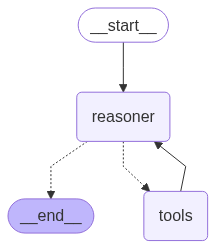

In [124]:
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage
from langgraph.graph import MessagesState
from typing import List, TypedDict
from langgraph.graph import START, StateGraph, END
from langgraph.prebuilt import tools_condition, ToolNode
from datetime import datetime
import json
# define the config
class ConfigSchema(TypedDict):
    database_name: str

# define state schema
class ReActState(TypedDict):
    messages: List[BaseMessage]
    tools_used: bool  # 👈 برای بررسی اینکه آیا ابزار استفاده شده یا نه

# system message
sys_msg = SystemMessage(content=REACT_SYS_PROMPT)

# نود reasoning
def reasoner(state: ReActState):
    print("Assistant is thinking...")
    msg_history = state["messages"]
    new_msg = model_with_tools.invoke([sys_msg] + msg_history)
    return {"messages": new_msg}

builder = StateGraph(MessagesState)
builder.add_node("reasoner", reasoner)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "reasoner")
builder.add_conditional_edges("reasoner", tools_condition)
builder.add_edge("tools", "reasoner")
builder.add_edge("reasoner", END)
react_graph = builder.compile()
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

#### Run and Evaluate (Estimated Run Time 20min)

**Task:** Execute the ReAct agent pipeline on the dataset and collect SQL outputs.

In [125]:
from method_run import run_method
import re
def run_react_agent_with_config(item):
    question = item['question']
    schema = item['schema']
    user_prompt = f"Question: {question}\nSchema: {schema}"
    input_msg = HumanMessage(content=user_prompt)
    input_config = {"configurable": {"database_name": item['db_id']}}
    response = react_graph.invoke(MessagesState(messages=[input_msg]), config=input_config)

    for msg in response["messages"]:
        msg.pretty_print()

    # If last AI Message is a list of messages, we need to extract the last one
    last_msg = response["messages"][-1].content
    if isinstance(last_msg, list):
        last_msg = last_msg[-1]

    # First try to extract query from markdown SQL block
    match = re.search(r'```sql\n(.*?)```', last_msg, re.DOTALL)
    if match:
        query = match.group(1).strip()
    else:
        # If no markdown block found, try to extract just SQL query
        query = last_msg.strip()
        # Remove any ```sql or ``` if present without proper formatting
        query = re.sub(r'```sql|```', '', query).strip()

    return {**item, 'sql': query}

#Run agent on mode=nano, it's not needed to run on full dataset
run_method(run_react_agent_with_config, SLEEP_TIME=20, mode="nano")

  0%|          | 0/5 [00:00<?, ?it/s]

Assistant is thinking...
Assistant is thinking...
================================ Human Message =================================

Question: Find the percentage of atoms with single bond. (Evidence: single bond refers to bond_type = '-'; percentage = DIVIDE(SUM(bond_type = '-'), COUNT(bond_id)) as percentage)
Schema: atom (atom_id, molecule_id, element)
bond (bond_id, molecule_id, bond_type)
connected (atom_id, atom_id2, bond_id)
molecule (molecule_id, label)

================================== Ai Message ==================================
Tool Calls:
  get_samples_from_table (c3248774-3162-46be-8c22-3de4b4e2e7f1)
 Call ID: c3248774-3162-46be-8c22-3de4b4e2e7f1
  Args:
    table_name: bond
  get_column_description (1cbd27d1-f67d-4bdf-a666-2761907b4c5d)
 Call ID: 1cbd27d1-f67d-4bdf-a666-2761907b4c5d
  Args:
    column_name: bond_type
    table_name: bond
  get_column_description (a9cd583e-d87c-4970-ab66-3b726c4a0684)
 Call ID: a9cd583e-d87c-4970-ab66-3b726c4a0684
  Args:
    column_name

 20%|██        | 1/5 [00:22<01:31, 23.00s/it]

Assistant is thinking...
Assistant is thinking...
Assistant is thinking...
Assistant is thinking...
================================ Human Message =================================

Question: What are the elements for bond id TR001_10_11? (Evidence: element = 'cl' means Chlorine; element = 'c' means Carbon; element = 'h' means Hydrogen; element = 'o' means Oxygen, element = 's' means Sulfur; element = 'n' means Nitrogen, element = 'p' means Phosphorus, element = 'na' means Sodium, element = 'br' means Bromine, element = 'f' means Fluorine; element = 'i' means Iodine; element = 'sn' means Tin; element = 'pb' means Lead; element = 'te' means Tellurium; element = 'ca' means Calcium)
Schema: atom (atom_id, molecule_id, element)
bond (bond_id, molecule_id, bond_type)
connected (atom_id, atom_id2, bond_id)
molecule (molecule_id, label)

================================== Ai Message ==================================
Tool Calls:
  get_samples_from_table (236d51f4-622d-40a7-9e20-2687e7db6ff3)


 40%|████      | 2/5 [00:52<01:20, 26.83s/it]

...

Assistant is thinking...
Assistant is thinking...
Assistant is thinking...
================================ Human Message =================================

Question: Find the name and date of events with expenses for pizza that were more than fifty dollars but less than a hundred dollars. (Evidence: name of event refers to event_name; date of event refers to event_date; expenses for pizza refers to expense_description = 'Pizza' where cost > 50 and cost < 100)
Schema: event (event_id, event_name, event_date, type, notes, location, status)
major (major_id, major_name, department, college)
zip_code (zip_code, type, city, county, state, short_state)
attendance (link_to_event, link_to_member)
budget (budget_id, category, spent, remaining, amount, event_status, link_to_event)
expense (expense_id, expense_description, expense_date, cost, approved, link_to_member, link_to_budget)
income (income_id, date_received, amount, source, notes, link_to_member)
member (member_id, first_name, last_name,

 80%|████████  | 4/5 [01:43<00:25, 25.87s/it]

Assistant is thinking...
Assistant is thinking...
Assistant is thinking...
================================ Human Message =================================

Question: Based on the total cost for all event, what is the percentage of cost for Yearly Kickoff event? (Evidence: DIVIDE(SUM(cost where event_name = 'Yearly Kickoff'), SUM(cost)) * 100)
Schema: event (event_id, event_name, event_date, type, notes, location, status)
major (major_id, major_name, department, college)
zip_code (zip_code, type, city, county, state, short_state)
attendance (link_to_event, link_to_member)
budget (budget_id, category, spent, remaining, amount, event_status, link_to_event)
expense (expense_id, expense_description, expense_date, cost, approved, link_to_member, link_to_budget)
income (income_id, date_received, amount, source, notes, link_to_member)
member (member_id, first_name, last_name, email, position, t_shirt_size, phone, zip, link_to_major)

================================== Ai Message =============

100%|██████████| 5/5 [02:09<00:00, 25.97s/it]

Starting to compare without knowledge for ex
Process finished successfully
start calculate
                     simple               moderate             challenging          total               
count                1                    1                    3                    5                   
======================================    ACCURACY    =====================================
accuracy             0.00                 100.00               66.67                60.00               
Finished evaluation

